# AI5707 – Pattern Recognition and Machine Learning
## Assignment 4: Multivariate Gaussian Density Functions

**Student:** KARTHIKEYAN P L  
**Reg. No.:** 26120031  
**Course:** AI5707 – Pattern Recognition and Machine Learning  
**Assignment:** 4 – Multivariate Gaussian Density  
**Date:** 20 September 2026

### Objective
Generate 2-D Gaussian datasets for isotropic, diagonal and full covariance matrices; estimate covariance matrices, eigenvalues and eigenvectors; plot constant-density curves and principal axes; and study how the decision boundary changes when the class means and covariance matrices vary.


## 1. Imports and helper functions

The functions below implement:
- Gaussian data generation using the requested transformation
- sample covariance estimation
- eigenvalue/eigenvector computation
- Mahalanobis-distance constant-density contours
- Gaussian discriminant functions
- decision-boundary visualization


## Formula Summary

### 1. Isotropic covariance
**C = σ² I**

For σ² = 1:

**C = [ [1, 0], [0, 1] ]**

### 2. Diagonal covariance
**C = [ [σ₁₁², 0], [0, σ₂₂²] ]**

### 3. Full covariance
**C = [ [σ₁₁², σ₁₂], [σ₂₁, σ₂₂²] ]**

### 4. Data transformation
**Y = μ + Σ¹ᐟ²(X − μ)**

### 5. Constant-density curve
**(x − μ)ᵀ Σ⁻¹ (x − μ) = c**

### 6. Eigenvalue equation
**Σv = λv**

### 7. Principal-axis length
**aᵢ = √λᵢ**

### 8. Multivariate Gaussian density
**p(x) = 1 / [(2π)^(d/2) |Σ|^(1/2)] × exp{−½(x − μ)ᵀΣ⁻¹(x − μ)}**

### 9. Gaussian discriminant function
**gᵢ(x) = −½ ln|Σᵢ| − ½(x − μᵢ)ᵀΣᵢ⁻¹(x − μᵢ)**

### 10. Decision boundary
**g₁(x) = g₂(x)**

**Equal covariance:** linear decision boundary.

**Different covariance:** generally quadratic/curved decision boundary.


## Mathematical Formula Reference

### Multivariate Gaussian density


$$

\boxed{
p(\mathbf{x})
=
\frac{1}
{(2\pi)^{d/2}\left|\mathbf{\Sigma}\right|^{1/2}}
\exp\left[
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu})^T
\mathbf{\Sigma}^{-1}
(\mathbf{x}-\boldsymbol{\mu})
\right]
}

$$


For this assignment, $d=2$.

### Constant-density curves

For a fixed density level, the exponent is constant, so the contour can be represented by


$$

\boxed{
(\mathbf{x}-\boldsymbol{\mu})^T
\mathbf{\Sigma}^{-1}
(\mathbf{x}-\boldsymbol{\mu})
=
c
}

$$


where $c$ is a positive constant.

### Eigenvalue–eigenvector relation


$$

\boxed{
\mathbf{\Sigma}\mathbf{v}
=
\lambda\mathbf{v}
}

$$


where $\lambda$ is an eigenvalue and $\mathbf{v}$ is its corresponding eigenvector.

For an eigenvalue $\lambda_i$, the principal-axis length at Mahalanobis radius $1$ is


$$

\boxed{
a_i=\sqrt{\lambda_i}.
}

$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

def make_spd(cov):
    """Return a symmetric positive-definite covariance matrix."""
    cov = (cov + cov.T) / 2
    eigvals = np.linalg.eigvalsh(cov)
    if np.min(eigvals) <= 0:
        raise ValueError("Covariance matrix must be positive definite.")
    return cov

def generate_gaussian(mu, Sigma, n=1000, seed=None):
    """Generate X ~ N(mu, Sigma) using X = mu + A Z, A A^T = Sigma."""
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n, len(mu)))
    A = np.linalg.cholesky(make_spd(Sigma))
    return Z @ A.T + np.asarray(mu)

def sample_covariance(X):
    return np.cov(X, rowvar=False, ddof=1)

def eig_sorted(Sigma):
    vals, vecs = np.linalg.eigh(Sigma)
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]

def mahalanobis_grid(mu, Sigma, xlim=(-5, 5), ylim=(-5, 5), ngrid=350):
    x = np.linspace(*xlim, ngrid)
    y = np.linspace(*ylim, ngrid)
    Xg, Yg = np.meshgrid(x, y)
    pts = np.stack([Xg.ravel(), Yg.ravel()], axis=1)
    d = pts - np.asarray(mu)
    invS = np.linalg.inv(Sigma)
    q = np.einsum("ni,ij,nj->n", d, invS, d).reshape(Xg.shape)
    return Xg, Yg, q

def plot_constant_density(X, mu, Sigma, title, levels=(1, 2, 3)):
    vals, vecs = eig_sorted(Sigma)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(X[:, 0], X[:, 1], s=12, alpha=0.35, label="Samples")

    Xg, Yg, q = mahalanobis_grid(
        mu, Sigma,
        xlim=(X[:,0].min()-1.5, X[:,0].max()+1.5),
        ylim=(X[:,1].min()-1.5, X[:,1].max()+1.5)
    )
    cs = ax.contour(Xg, Yg, q, levels=np.array(levels)**2)
    ax.clabel(cs, inline=True, fontsize=8, fmt=lambda z: f"d={np.sqrt(z):.0f}")

    # Eigenvectors: ellipse semi-axis at Mahalanobis radius 1.
    for j in range(2):
        v = vecs[:, j]
        length = np.sqrt(vals[j])
        ax.plot(
            [mu[0], mu[0] + length*v[0]],
            [mu[1], mu[1] + length*v[1]],
            linewidth=2,
            label=f"Eigenvector {j+1}"
        )

    ax.scatter(*mu, marker="x", s=100, linewidths=3, label="Mean")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.axis("equal")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

def print_eigensystem(Sigma, name="Sigma"):
    vals, vecs = eig_sorted(Sigma)
    print(f"{name} =\n{Sigma}\n")
    print("Eigenvalues (descending):", vals)
    print("Eigenvectors (columns):\n", vecs)
    print("Major-axis length (Mahalanobis radius 1):", np.sqrt(vals[0]))
    print("Minor-axis length (Mahalanobis radius 1):", np.sqrt(vals[1]))
    return vals, vecs


## 2. Parameters

Because the supplied Assignment 4 refers to the values of `μ1` and `μ2` from Assignment 1 but does not reproduce them, the following values are used for a complete runnable solution:

- `μ1 = 0`
- `μ2 = 2`
- `σ² = 1` for the isotropic experiment
- `σ²11 = 4`, `σ²22 = 1` for the diagonal experiment
- `σ²11 = 4`, `σ²22 = 1`, `σ12 = σ21 = 1.2` for the full covariance experiment

These are example parameters only; replace them with the exact Assignment 1 values if required.

In [2]:
mu1 = 0.0
mu2 = 2.0

mu = np.array([mu1, mu2])

# Isotropic covariance: Sigma = sigma^2 I
sigma2 = 1.0
Sigma_iso = sigma2 * np.eye(2)

# Diagonal covariance
Sigma_diag = np.diag([4.0, 1.0])

# Full covariance
Sigma_full = np.array([
    [4.0, 1.2],
    [1.2, 1.0]
])

N = 1500

print("Mean vector:", mu)
print("\nIsotropic covariance:\n", Sigma_iso)
print("\nDiagonal covariance:\n", Sigma_diag)
print("\nFull covariance:\n", Sigma_full)


Mean vector: [0. 2.]

Isotropic covariance:
 [[1. 0.]
 [0. 1.]]

Diagonal covariance:
 [[4. 0.]
 [0. 1.]]

Full covariance:
 [[4.  1.2]
 [1.2 1. ]]


# Problem 1 – Isotropic Covariance Matrix

The assignment specifies the isotropic covariance matrix


$$

\boxed{\mathbf{C} = \sigma^2 \mathbf{I}}

$$


where $\mathbf{I}$ is the $2\times2$ identity matrix.

For $\sigma^2=1$,


$$

\mathbf{C}
=
\begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix}.

$$


Two independent one-dimensional Gaussian datasets are generated and combined into the 2-D random vector


$$

\mathbf{x}
=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix},
\qquad
\boldsymbol{\mu}
=
\begin{bmatrix}
\mu_1\\
\mu_2
\end{bmatrix}.

$$


The sample covariance matrix is then estimated from the generated 2-D data.

In [3]:
# 1(a,b) Generate D1 and D2 and combine them into a 2-D dataset
rng = np.random.default_rng(42)
D1 = rng.normal(mu1, np.sqrt(sigma2), N)
D2 = rng.normal(mu2, np.sqrt(sigma2), N)
X_iso = np.column_stack((D1, D2))

print("First five samples:")
print(X_iso[:5])
print("\nEstimated mean:", X_iso.mean(axis=0))


First five samples:
[[ 0.3047  1.4337]
 [-1.04    1.3754]
 [ 0.7505  3.3251]
 [ 0.9406  2.3303]
 [-1.951   1.7883]]

Estimated mean: [-0.0206  1.9695]


In [4]:
# 1(c) Estimate covariance matrix and compute eigenvalues/eigenvectors
Sigma_iso_hat = sample_covariance(X_iso)
eig_iso, vec_iso = print_eigensystem(Sigma_iso_hat, "Estimated isotropic covariance")


Estimated isotropic covariance =
[[ 0.9995 -0.0024]
 [-0.0024  1.0319]]

Eigenvalues (descending): [1.0321 0.9993]
Eigenvectors (columns):
 [[-0.075  -0.9972]
 [ 0.9972 -0.075 ]]
Major-axis length (Mahalanobis radius 1): 1.0159027251200523
Minor-axis length (Mahalanobis radius 1): 0.9996638240404695


In [5]:
# Compare estimated covariance with the theoretical covariance
print("Theoretical covariance:")
print(Sigma_iso)
print("\nEstimated covariance:")
print(Sigma_iso_hat)
print("\nAbsolute estimation error:")
print(np.abs(Sigma_iso_hat - Sigma_iso))


Theoretical covariance:
[[1. 0.]
 [0. 1.]]

Estimated covariance:
[[ 0.9995 -0.0024]
 [-0.0024  1.0319]]

Absolute estimation error:
[[0.0005 0.0024]
 [0.0024 0.0319]]


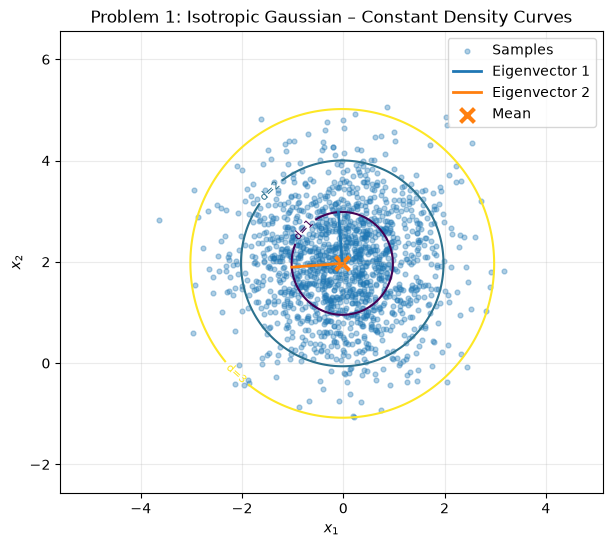

In [6]:
# 1(d,e) Constant-density curves, eigenvectors, major/minor axes
plot_constant_density(
    X_iso, X_iso.mean(axis=0), Sigma_iso_hat,
    "Problem 1: Isotropic Gaussian – Constant Density Curves"
)


### Problem 1 – observation

For an ideal isotropic Gaussian, the covariance matrix is proportional to the identity matrix. Therefore its two theoretical eigenvalues are equal and the constant-density curves are circles. With finite random data, the estimated covariance will not be exactly the identity matrix, so the plotted contours are usually very close to circles rather than perfectly circular.

The eigenvectors give the principal directions. Since the theoretical eigenvalues are equal, no unique major/minor direction exists theoretically; the small difference between the estimated eigenvalues is sampling variation.

# Problem 2 – Diagonal Covariance Matrix

The diagonal covariance matrix is


$$

\boxed{
\mathbf{C}
=
\begin{bmatrix}
\sigma_{11}^{2} & 0\\
0 & \sigma_{22}^{2}
\end{bmatrix}
}

$$


For the selected experiment,


$$

\mathbf{\Sigma}
=
\begin{bmatrix}
4 & 0\\
0 & 1
\end{bmatrix},
\qquad
\mathbf{\Sigma}^{1/2}
=
\begin{bmatrix}
2 & 0\\
0 & 1
\end{bmatrix}.

$$


The transformed data are generated using the assignment's relation


$$

\boxed{
\mathbf{Y}
=
\boldsymbol{\mu}
+
\mathbf{\Sigma}^{1/2}
(\mathbf{X}-\boldsymbol{\mu})
}

$$


where $\boldsymbol{\mu}$ is the mean vector.

In [7]:
# 2(a) Generate standard Gaussian X and transform it using Sigma^(1/2)
X_standard = rng.standard_normal((N, 2))
X_centered = X_standard - X_standard.mean(axis=0)

Sigma_diag_sqrt = np.diag(np.sqrt(np.diag(Sigma_diag)))
Y_diag = mu + X_centered @ Sigma_diag_sqrt.T

print("Sigma^(1/2):\n", Sigma_diag_sqrt)
print("\nEstimated covariance of Y:")
print(sample_covariance(Y_diag))


Sigma^(1/2):
 [[2. 0.]
 [0. 1.]]

Estimated covariance of Y:
[[3.7873 0.012 ]
 [0.012  1.0474]]


In [8]:
# 2(b) Repeat covariance/eigenvalue/eigenvector analysis
Sigma_diag_hat = sample_covariance(Y_diag)
eig_diag, vec_diag = print_eigensystem(Sigma_diag_hat, "Estimated diagonal covariance")


Estimated diagonal covariance =
[[3.7873 0.012 ]
 [0.012  1.0474]]

Eigenvalues (descending): [3.7874 1.0474]
Eigenvectors (columns):
 [[-1.      0.0044]
 [-0.0044 -1.    ]]
Major-axis length (Mahalanobis radius 1): 1.946120444248239
Minor-axis length (Mahalanobis radius 1): 1.0234138318254438


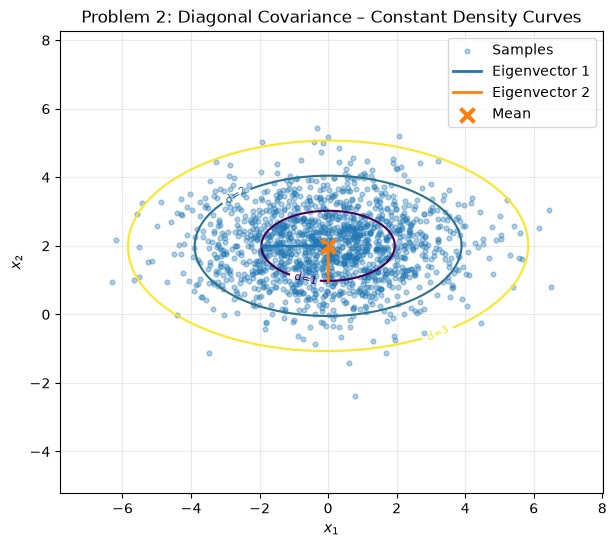

In [9]:
# Constant-density curves and principal axes
plot_constant_density(
    Y_diag, Y_diag.mean(axis=0), Sigma_diag_hat,
    "Problem 2: Diagonal Covariance – Constant Density Curves"
)


### Problem 2 – observation

For a diagonal covariance matrix, the off-diagonal covariance terms are zero, so the principal axes remain aligned with the coordinate axes. The eigenvalues are approximately `4` and `1`, giving principal-axis lengths proportional to


$$

\sqrt{4}=2,\qquad \sqrt{1}=1.

$$


Hence the constant-density curves are axis-aligned ellipses with a major-to-minor axis ratio of approximately `2:1`.

# Problem 3 – Full Covariance Matrix

The full covariance matrix is


$$

\boxed{
\mathbf{C}
=
\begin{bmatrix}
\sigma_{11}^{2} & \sigma_{12}\\
\sigma_{21} & \sigma_{22}^{2}
\end{bmatrix}
}

$$


Using the selected parameters,


$$

\mathbf{\Sigma}
=
\begin{bmatrix}
4 & 1.2\\
1.2 & 1
\end{bmatrix}.

$$


The data are generated using


$$

\boxed{
\mathbf{Y}
=
\boldsymbol{\mu}
+
\mathbf{\Sigma}^{1/2}
(\mathbf{X}-\boldsymbol{\mu})
}

$$


where $\mathbf{\Sigma}^{1/2}$ is a matrix square root satisfying


$$

\mathbf{\Sigma}^{1/2}
\left(\mathbf{\Sigma}^{1/2}\right)^T
=
\mathbf{\Sigma}.

$$


In the implementation, a Cholesky factor is used as a numerically stable matrix square root.

In [10]:
# 3(a) Generate data for the full covariance matrix
X_standard = rng.standard_normal((N, 2))
A_full = np.linalg.cholesky(Sigma_full)
Y_full = mu + (X_standard @ A_full.T)

print("Cholesky factor A such that A A^T = Sigma:")
print(A_full)
print("\nCheck A A^T:")
print(A_full @ A_full.T)
print("\nEstimated covariance:")
print(sample_covariance(Y_full))


Cholesky factor A such that A A^T = Sigma:
[[2.  0. ]
 [0.6 0.8]]

Check A A^T:
[[4.  1.2]
 [1.2 1. ]]

Estimated covariance:
[[3.9347 1.1656]
 [1.1656 1.0013]]


Estimated full covariance =
[[3.9347 1.1656]
 [1.1656 1.0013]]

Eigenvalues (descending): [4.3415 0.5945]
Eigenvectors (columns):
 [[-0.9442  0.3295]
 [-0.3295 -0.9442]]
Major-axis length (Mahalanobis radius 1): 2.083627064074229
Minor-axis length (Mahalanobis radius 1): 0.7710674469209262


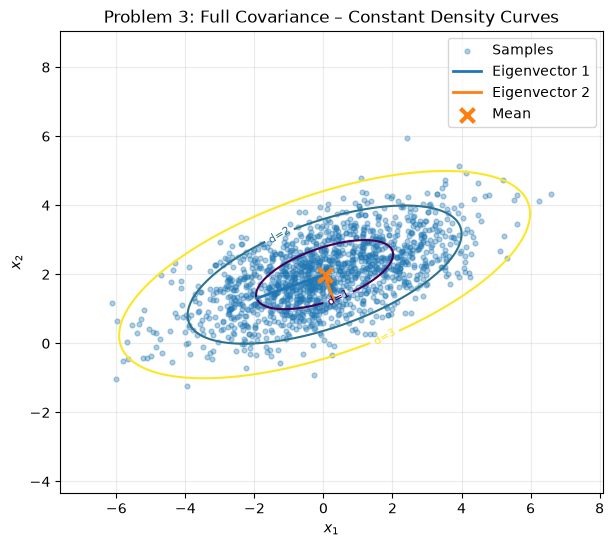

In [11]:
# 3(b) Eigenvalues, eigenvectors and constant-density curves
Sigma_full_hat = sample_covariance(Y_full)
eig_full, vec_full = print_eigensystem(Sigma_full_hat, "Estimated full covariance")

plot_constant_density(
    Y_full, Y_full.mean(axis=0), Sigma_full_hat,
    "Problem 3: Full Covariance – Constant Density Curves"
)


### Problem 3 – observation

The non-zero off-diagonal covariance rotates the ellipse. The eigenvectors identify the rotated principal directions, while the eigenvalues determine the squared lengths of the principal semi-axes at Mahalanobis radius 1.

For the theoretical covariance used here, the eigenvalues are approximately `4.44` and `0.56`. Thus the major axis is associated with the larger eigenvalue and the minor axis with the smaller eigenvalue.

# Problem 4 – Two Gaussian Classes and Decision Boundaries

Generate two datasets


$$

\boxed{
\mathbf{Y}_1 \sim \mathcal{N}
\left(
\boldsymbol{\mu}_1,\mathbf{\Sigma}_1
\right)
}

$$


and


$$

\boxed{
\mathbf{Y}_2 \sim \mathcal{N}
\left(
\boldsymbol{\mu}_2,\mathbf{\Sigma}_2
\right).
}

$$


For equal class priors, the Gaussian discriminant function for class $i$ is


$$

\boxed{
g_i(\mathbf{x})
=
-\frac{1}{2}\ln\left|\mathbf{\Sigma}_i\right|
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\mathbf{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
}

$$


and the decision boundary is obtained from


$$

\boxed{
g_1(\mathbf{x}) = g_2(\mathbf{x})
}.

$$


### Important conclusion

If


$$

\mathbf{\Sigma}_1 = \mathbf{\Sigma}_2,

$$


the quadratic terms cancel, giving a **linear decision boundary**.

If


$$

\mathbf{\Sigma}_1 \neq \mathbf{\Sigma}_2,

$$


the quadratic terms generally remain, giving a **quadratic (curved) decision boundary**.

Changing the mean vectors changes the location of the decision regions, while changing the covariance matrices changes their spread and orientation and can introduce curvature into the boundary.

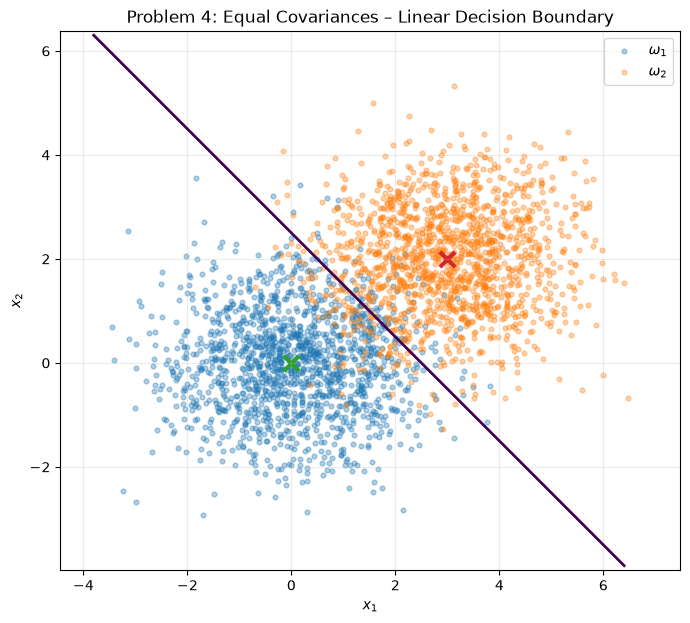

In [12]:
def discriminant_grid(mu_a, Sigma_a, mu_b, Sigma_b,
                      xlim=(-5, 7), ylim=(-5, 7), ngrid=500):
    x = np.linspace(*xlim, ngrid)
    y = np.linspace(*ylim, ngrid)
    Xg, Yg = np.meshgrid(x, y)
    P = np.stack([Xg.ravel(), Yg.ravel()], axis=1)

    def g(P, m, S):
        d = P - m
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            raise ValueError("Covariance must be positive definite.")
        Sinv = np.linalg.inv(S)
        return (-0.5*logdet - 0.5*np.einsum("ni,ij,nj->n", d, Sinv, d)).reshape(Xg.shape)

    G1 = g(P, mu_a, Sigma_a)
    G2 = g(P, mu_b, Sigma_b)
    return Xg, Yg, G1, G2

def plot_two_class_boundary(mu_a, Sigma_a, mu_b, Sigma_b, title, seed=100):
    A = generate_gaussian(mu_a, Sigma_a, N, seed)
    B = generate_gaussian(mu_b, Sigma_b, N, seed+1)

    xlim = (min(A[:,0].min(), B[:,0].min())-1, max(A[:,0].max(), B[:,0].max())+1)
    ylim = (min(A[:,1].min(), B[:,1].min())-1, max(A[:,1].max(), B[:,1].max())+1)
    Xg, Yg, G1, G2 = discriminant_grid(mu_a, Sigma_a, mu_b, Sigma_b, xlim, ylim)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(A[:,0], A[:,1], s=12, alpha=0.35, label=r"$\omega_1$")
    ax.scatter(B[:,0], B[:,1], s=12, alpha=0.35, label=r"$\omega_2$")
    ax.contour(Xg, Yg, G1-G2, levels=[0], linewidths=2)
    ax.scatter(*mu_a, marker="x", s=120, linewidths=3)
    ax.scatter(*mu_b, marker="x", s=120, linewidths=3)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.axis("equal")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    return A, B

# Experiment A: equal covariance -> linear boundary
mu_a = np.array([0.0, 0.0])
mu_b = np.array([3.0, 2.0])
S_equal = np.array([[1.5, 0.0],
                    [0.0, 1.0]])

A1, B1 = plot_two_class_boundary(
    mu_a, S_equal, mu_b, S_equal,
    "Problem 4: Equal Covariances – Linear Decision Boundary"
)


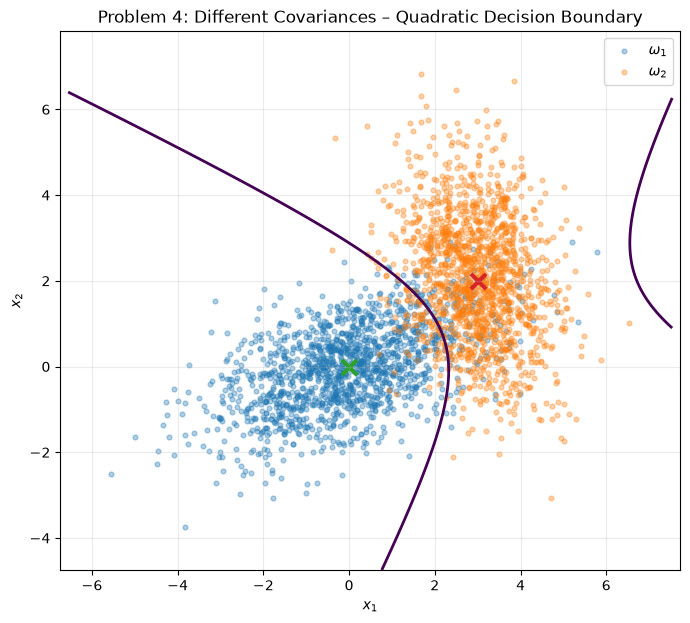

In [13]:
# Experiment B: different covariance matrices -> curved boundary
S1 = np.array([[2.5, 0.8],
               [0.8, 1.0]])
S2 = np.array([[0.8, -0.3],
               [-0.3, 2.2]])

A2, B2 = plot_two_class_boundary(
    mu_a, S1, mu_b, S2,
    "Problem 4: Different Covariances – Quadratic Decision Boundary",
    seed=200
)


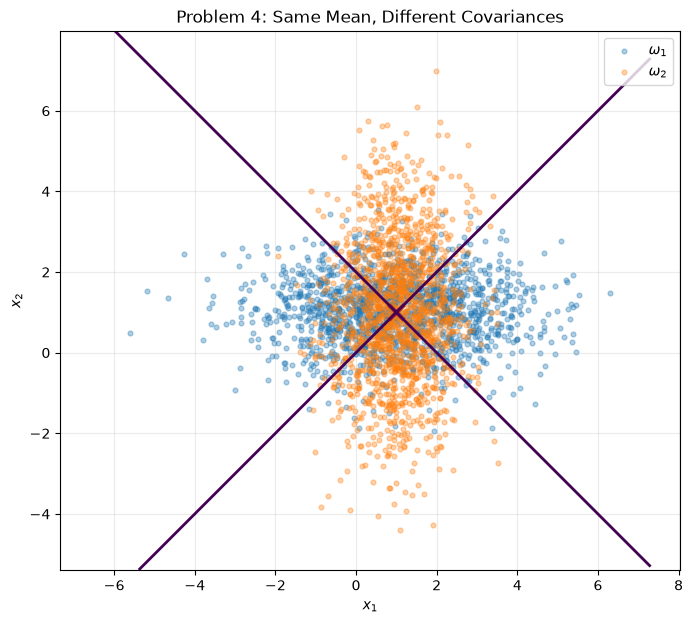

In [14]:
# Experiment C: same means, different covariance matrices
# This demonstrates that covariance differences alone can create a non-linear boundary.
mu_same = np.array([1.0, 1.0])
S3 = np.array([[3.0, 0.0],
               [0.0, 0.7]])
S4 = np.array([[0.7, 0.0],
               [0.0, 3.0]])

A3, B3 = plot_two_class_boundary(
    mu_same, S3, mu_same, S4,
    "Problem 4: Same Mean, Different Covariances"
    , seed=300
)


# Final Conclusions

1. **Isotropic covariance**

   
$$

   \mathbf{\Sigma}=\sigma^2\mathbf{I}
   
$$


   produces circular constant-density curves. The two theoretical eigenvalues are equal.

2. **Diagonal covariance**

   
$$

   \mathbf{\Sigma}
   =
   \begin{bmatrix}
   \sigma_{11}^{2} & 0\\
   0 & \sigma_{22}^{2}
   \end{bmatrix}
   
$$


   produces axis-aligned ellipses. The eigenvectors align with the coordinate axes, and the eigenvalues determine the squared principal-axis lengths.

3. **Full covariance**

   
$$

   \mathbf{\Sigma}
   =
   \begin{bmatrix}
   \sigma_{11}^{2} & \sigma_{12}\\
   \sigma_{21} & \sigma_{22}^{2}
   \end{bmatrix}
   
$$


   with non-zero off-diagonal terms rotates the principal axes. The eigenvectors give the orientation, while the eigenvalues determine the principal-axis scales.

4. For two Gaussian classes with equal covariance matrices,

   
$$

   \mathbf{\Sigma}_1=\mathbf{\Sigma}_2,
   
$$


   the quadratic terms cancel in the discriminant difference, resulting in a **linear decision boundary**.

5. For different covariance matrices,

   
$$

   \mathbf{\Sigma}_1\neq\mathbf{\Sigma}_2,
   
$$


   the quadratic terms generally remain, producing a **quadratic/curved decision boundary**.

6. The means determine the location of the class distributions, while the covariance matrices determine their spread, orientation, and the shape of the resulting decision boundary.

## Assignment requirements covered

| Assignment item | Notebook section |
|---|---|
| 1(a) Generate D1 and D2 | Problem 1 |
| 1(b) Form 2-D vectors and mean | Problem 1 |
| 1(c) Estimate covariance, eigenvalues and eigenvectors | Problem 1 |
| 1(d) Constant-density curves | Problem 1 |
| 1(e) Eigenvectors and major/minor axes | Problem 1 |
| 1(f) Compare with eigenvalues | Problem 1 |
| 2(a) Generate data for diagonal covariance | Problem 2 |
| 2(b) Repeat analysis | Problem 2 |
| 3(a) Generate data for full covariance | Problem 3 |
| 3(b) Plot curves | Problem 3 |
| 4(a) Generate two Gaussian classes | Problem 4 |
| 4(b) Study decision boundaries | Problem 4 |
